2021-11-30 ~ 2023-12-01 까지 2년치 매일 30건씩

주차로 묶어서 시각화

# Figure 1(Difficulty)

In [1]:
import pandas as pd
import re
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import lib.stats.stats as st
import lib.annotation.Result_Prep as rp
import config.config as conf
import matplotlib as mpl
import matplotlib.lines as mlines
import os

INFO 01-11 20:15:50 [__init__.py:216] Automatically detected platform cuda.


In [2]:
path = f'{conf.DATA_PATH}/data/llm_annotation_result/models--cyankiwi--Qwen3-30B-A3B-Instruct-2507-AWQ-4bit' 
file_list = os.listdir(path)

In [3]:
r_p = rp.Result_Prep()

In [4]:
ver_list_5 = sorted([y for y in [x for x in file_list if x.isdigit()] if (int(y)>=50000) & (int(y)<60000)])
ver_list_10 = sorted([y for y in [x for x in file_list if x.isdigit()] if (int(y)>=100000) & (int(y)<110000)])


In [5]:
ver_list = ver_list_5 + ver_list_10
print(ver_list)

['100185', '100186', '100187', '100188', '100189', '100190', '100191', '100192', '100193', '100194', '100195', '100196', '100197', '100198', '100199', '100200', '100201', '100202', '100203', '100204', '100205', '100206', '100207', '100208', '100209', '100210', '100211', '100212', '100213', '100214', '100215', '100216', '100217', '100218', '100219', '100220', '100221', '100222', '100223', '100224', '100225', '100226', '100227', '100228', '100229', '100230', '100231', '100232', '100233', '100234', '100235', '100236', '100237', '100238', '100239', '100240', '100241', '100242', '100243', '100244', '100245', '100246', '100247', '100248', '100249', '100250', '100251', '100252', '100253', '100254', '100255', '100256', '100257', '100258', '100259', '100260', '100261', '100262', '100263', '100264', '100265', '100266', '100267', '100268', '100269', '100270', '100271', '100272', '100273', '100274', '100275', '100276', '100277', '100278', '100279', '100280', '100281', '100282', '100283', '100284',

In [6]:
tot_calc = pd.DataFrame()
df = pd.DataFrame()
for listid in ver_list:
    df = r_p.make_one_file(listid, path)
    if isinstance(df, pd.core.frame.DataFrame):
        df = r_p.pp_df(df, 5)
        df = r_p.calc_rate_byweek(df)
        tot_calc = pd.concat([tot_calc, df], axis = 0)

tot_calc.sort_values(by = ['rel_week'], ascending=True, inplace=True)    

/usr/share/d_ollama/data/llm_annotation_result/models--cyankiwi--Qwen3-30B-A3B-Instruct-2507-AWQ-4bit/100185/param.json
/usr/share/d_ollama/data/llm_annotation_result/models--cyankiwi--Qwen3-30B-A3B-Instruct-2507-AWQ-4bit/100185/llm_config.json
/usr/share/d_ollama/data/llm_annotation_result/models--cyankiwi--Qwen3-30B-A3B-Instruct-2507-AWQ-4bit/100185/2021-11-10 00:00:00.csv
/usr/share/d_ollama/data/llm_annotation_result/models--cyankiwi--Qwen3-30B-A3B-Instruct-2507-AWQ-4bit/100186/param.json
/usr/share/d_ollama/data/llm_annotation_result/models--cyankiwi--Qwen3-30B-A3B-Instruct-2507-AWQ-4bit/100186/llm_config.json
/usr/share/d_ollama/data/llm_annotation_result/models--cyankiwi--Qwen3-30B-A3B-Instruct-2507-AWQ-4bit/100186/2021-12-10 00:00:00.csv
/usr/share/d_ollama/data/llm_annotation_result/models--cyankiwi--Qwen3-30B-A3B-Instruct-2507-AWQ-4bit/100187/param.json
/usr/share/d_ollama/data/llm_annotation_result/models--cyankiwi--Qwen3-30B-A3B-Instruct-2507-AWQ-4bit/100187/llm_config.json

In [7]:
m_chk_cnt_0 = tot_calc[tot_calc['o_result'] =='0']
m_chk_cnt_1 = tot_calc[tot_calc['o_result'] =='1']
m_chk_cnt_2 = tot_calc[tot_calc['o_result'] =='2']

In [8]:
m_chk_cnt_0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180 entries, 0 to 0
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rel_week  180 non-null    float64
 1   o_result  180 non-null    object 
 2   r_cnt     180 non-null    int64  
 3   tot_cnt   180 non-null    int64  
 4   rate      180 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 8.4+ KB


In [9]:
print(m_chk_cnt_0.loc[m_chk_cnt_0['o_result'].isna(), 'rate'])
print(m_chk_cnt_1.loc[m_chk_cnt_1['o_result'].isna(), 'rate'])
print(m_chk_cnt_2.loc[m_chk_cnt_2['o_result'].isna(), 'rate'])

Series([], Name: rate, dtype: float64)
Series([], Name: rate, dtype: float64)
Series([], Name: rate, dtype: float64)


In [10]:
m_chk_cnt_0.loc[:, 'o_result'] = '0'
m_chk_cnt_1.loc[:, 'o_result'] = '1'
m_chk_cnt_2.loc[:, 'o_result'] = '2'

In [11]:
def calc_stats(df):
    x = df['rel_week'].values
    y = df['rate'].values
    st_ = st.Stats(x, y, 2, 0.95)
    F_stat, p_value = st_.chow_test()

    return x, y, st_, F_stat, p_value


In [12]:
x = m_chk_cnt_0[(m_chk_cnt_0['rel_week'] >=-52) & (m_chk_cnt_0['rel_week'] <52)].rel_week.values

In [13]:
m_chk_cnt_0


,rel_week,o_result,r_cnt,tot_cnt,rate
0,-55.0,0,5,14,35.714286
0,-55.0,0,6,20,30.000000
0,-55.0,0,9,22,40.909091
0,-55.0,0,9,24,37.500000
0,-55.0,0,5,22,22.727273
...,...,...,...,...,...
0,101.0,0,3,20,15.000000
0,101.0,0,3,27,11.111111
0,101.0,0,3,23,13.043478
0,101.0,0,2,18,11.111111


In [14]:
result_dict = \
{0 : {0:  calc_stats(m_chk_cnt_0[(m_chk_cnt_0['rel_week'] >=-52) & (m_chk_cnt_0['rel_week'] <52)]),
        1 : calc_stats(m_chk_cnt_0[(m_chk_cnt_0['rel_week'] >=0) & (m_chk_cnt_0['rel_week'] <104)])},

1 : {0:  calc_stats(m_chk_cnt_1[(m_chk_cnt_1['rel_week'] >=-52) & (m_chk_cnt_1['rel_week'] <52)]),
       1:  calc_stats(m_chk_cnt_1[(m_chk_cnt_1['rel_week'] >= 0) & (m_chk_cnt_1['rel_week'] < 104)])},

2 : {0:  calc_stats(m_chk_cnt_2[(m_chk_cnt_2['rel_week'] >=-52) & (m_chk_cnt_2['rel_week'] <52)]),
       1:  calc_stats(m_chk_cnt_2[(m_chk_cnt_2['rel_week'] >= 0) & (m_chk_cnt_2['rel_week'] < 104)])}
}

In [15]:
calc_stats(m_chk_cnt_0[(m_chk_cnt_0['rel_week'] >=-52) & (m_chk_cnt_0['rel_week'] <52)])

(array([-51., -51., -51., -51., -51., -47., -47., -47., -47., -47., -42.,
        -42., -42., -42., -42., -38., -38., -38., -38., -38., -34., -34.,
        -34., -34., -34., -30., -30., -30., -30., -30., -25., -25., -25.,
        -25., -25., -21., -21., -21., -21., -21., -16., -16., -16., -16.,
        -16., -12., -12., -12., -12., -12.,  -8.,  -8.,  -8.,  -8.,  -8.,
         -3.,  -3.,  -3.,  -3.,  -3.,   1.,   1.,   1.,   1.,   1.,   5.,
          5.,   5.,   5.,   5.,  10.,  10.,  10.,  10.,  10.,  14.,  14.,
         14.,  14.,  14.,  18.,  18.,  18.,  18.,  18.,  23.,  23.,  23.,
         23.,  23.,  27.,  27.,  27.,  27.,  27.,  31.,  31.,  31.,  31.,
         31.,  36.,  36.,  36.,  36.,  36.,  40.,  40.,  40.,  40.,  40.,
         44.,  44.,  44.,  44.,  44.,  49.,  49.,  49.,  49.,  49.]),
 array([18.18181818, 36.        , 33.33333333, 46.15384615, 34.7826087 ,
        29.62962963, 35.71428571, 31.81818182, 39.13043478, 21.42857143,
        13.63636364, 40.        , 37.5      

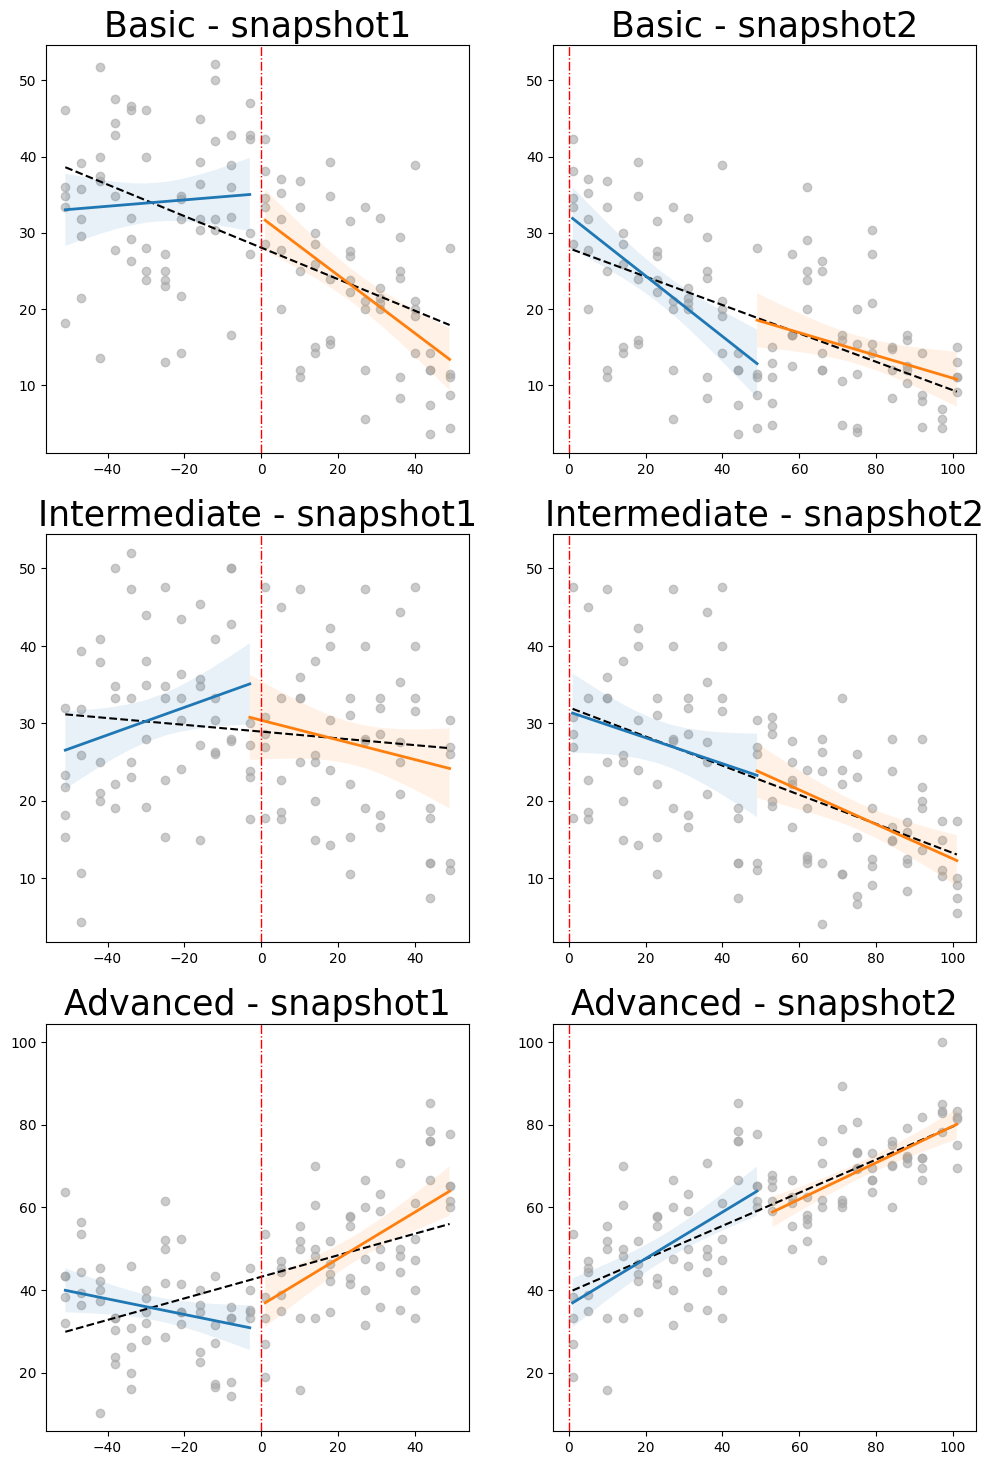

In [ ]:
fig, axs = plt.subplots(3, 2, figsize = (12, 18))

diff_dict = {0 : 'Basic', 1 : 'Intermediate', 2 : 'Advanced'}
snapshot_dict = {0 : 'snapshot1', 1 : 'snapshot2'}

for x_idx, snap_dict in result_dict.items():
    axs[x_idx, 1].sharey(axs[x_idx, 0])
    for y_idx, st_param in snap_dict.items():
        x = st_param[0]
        split_idx = int(len(x)/2)
        x_0_1 = x[:split_idx]
        x_0_2 = x[split_idx:]
        p_value_txt = '($p < 0.001$)' if st_param[4] <0.001 else f'($p = {p_value_0:.3f}$)'

        axs[x_idx][y_idx].scatter(st_param[0], st_param[1],  alpha=0.6, color='darkgray')
        axs[x_idx][y_idx].plot(st_param[0], st_param[2].y_predict, label="Overall Fit", linestyle="--", color="black")  

        axs[x_idx][y_idx].plot(x_0_1, st_param[2].y1_predict, label="before ChatGPT", linewidth='2')

        axs[x_idx][y_idx].fill_between(x_0_1, st_param[2].y1_predict - st_param[2].y1_conf_interval, st_param[2].y1_predict + st_param[2].y1_conf_interval, alpha=0.1)

        axs[x_idx][y_idx].plot(x_0_2, st_param[2].y2_predict, label="after ChatGPT", linewidth='2')
        axs[x_idx][y_idx].fill_between(x_0_2, st_param[2].y2_predict - st_param[2].y2_conf_interval, st_param[2].y2_predict + st_param[2].y2_conf_interval, alpha=0.1)

        axs[x_idx][y_idx].axvline(x=0,     color='red',    linestyle='-.', linewidth=1)
        axs[x_idx][y_idx].set_title(f"{diff_dict[x_idx]} - {snapshot_dict[y_idx]} ($p < {np.round(st_param[4], 3)})", fontsize=25)

        axs[idx].text(0.5, 1.05, f"Changes in Entropy (topic)",
            ha='center', va='bottom', fontsize=22, fontweight='bold', transform=axs[idx].transAxes)

        axs[idx].text(0.5, 1.00, f"{p_value_txt}",
                ha='center', va='bottom', fontsize=15, transform=axs[idx].transAxes)  
        